# **競賽二(空拍圖生成線條)**

## **Import Packages**

In [1]:
!pip install torchsummary
!pip install git+https://github.com/lartpang/PySODMetrics.git

  Cloning https://github.com/lartpang/PySODMetrics.git to /tmp/pip-req-build-o4je330u
  Running command git clone --filter=blob:none --quiet https://github.com/lartpang/PySODMetrics.git /tmp/pip-req-build-o4je330u
  Resolved https://github.com/lartpang/PySODMetrics.git to commit 4b1091a474133a4dfd3b1220b63a6669c8b1e774
  Installing build dependencies ... - \ | / - \ done
  Getting requirements to build wheel ... - done
  Preparing metadata (pyproject.toml) ... - done
  Created wheel for pysodmetrics: filename=pysodmetrics-1.4.2-py3-none-any.whl size=16108 sha256=1dd5197a975da416f5ebe663a9f2464fb9ef7f14c20736395dfbf2715f69f0da
  Stored in directory: /tmp/pip-ephem-wheel-cache-jynf_npy/wheels/05/9f/5b/1f408258fcd0b5808871e08e28be7e42641780675d753c1932
Successfully built pysodmetrics


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary

from torch.utils.tensorboard import SummaryWriter
import torchvision.transforms as transforms
from torchvision.transforms import RandomApply, RandomHorizontalFlip,RandomVerticalFlip
import torchvision.models as models
from PIL import Image , ImageFilter , ImageEnhance
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
#!pip install git+https://github.com/lartpang/PySODMetrics.git
from py_sod_metrics import Fmeasure ,FmeasureHandler ,FmeasureV2
#!pip install git+https://github.com/Po-Hsun-Su/pytorch-ssim.git
import shutil


2024-05-27 13:57:11.079774: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-05-27 13:57:11.079869: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-05-27 13:57:11.177314: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
def process_image(image):

    r , g , b = image.split()
    Sobel_image1 = Sobel_image(image)
    image = Image.merge("RGB", (r, Sobel_image1, b))


    return image 

def apply_clahe(image, clip_limit=2.0, grid_size=(8, 8)):
    image_np = np.array(image)
    lab = cv2.cvtColor(image_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)
    enhanced_l = clahe.apply(l)

    lab = cv2.merge((enhanced_l, a, b))
    enhanced_image = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

    enhanced_image = Image.fromarray(enhanced_image)
    return enhanced_image

def Sobel_image(image):
    gray = np.array(image)
    sobelx = cv2.Sobel(gray, cv2.CV_16S, 1, 0, ksize=3)  # 水平方向
    sobely = cv2.Sobel(gray, cv2.CV_16S, 0, 1, ksize=3)  # 垂直方向

    absX = cv2.convertScaleAbs(sobelx) 
    absY = cv2.convertScaleAbs(sobely) 

    dst = cv2.addWeighted(absX, 1, absY, 1, 0)
    dst = cv2.GaussianBlur(dst, (3, 3), 0)
    #covert cv2 to PIL L
    dst = Image.fromarray(dst)
    dst = dst.convert('L')
    return dst


def hsv_image(image):
    image = np.array(image)
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hue, saturation, value = cv2.split(hsv_image) 
    #轉成torch tensor
    hsv = torch.tensor(saturation)#3 channel 
    hsv = hsv.unsqueeze(0)
    return hsv

## **Dataset, DataLoader, and Transforms**

In [4]:
class GeneralDataset(Dataset): # 用於 training set 和 validation set 的 Dataset
    def __init__(self, image_root, gt_root, img_size, mode='train'):
        assert mode in ['train', 'val'] # mode 必須是' train' 或 'val'
        self.img_size = img_size
        self.mode = mode
        self.images = sorted([os.path.join(image_root, f) for f in os.listdir(image_root) if f.endswith('.jpg')])
        self.gts = sorted([os.path.join(gt_root, f) for f in os.listdir(gt_root) if f.endswith('.png')])
        self.filter_files()

        # image 預處理操作: 調整大小、轉換為 Tensor、標準化
        self.img_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])

        # ground truth 預處理操作: 調整大小並轉換為 Tensor
        self.gt_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor()])
        

        self.da_transform = transforms.Compose([
                    transforms.Resize((self.img_size, self.img_size)),
                    RandomApply([transforms.RandomHorizontalFlip()], p=0.5),
                    RandomApply([transforms.RandomVerticalFlip()], p=0.5),
                    #RandomApply([transforms.RandomRotation((90,90))], p=0.5),
                    #RandomApply([transforms.RandomAffine(degrees=0, scale=(0.8, 0.8))], p=0.25),
                ])

    def __getitem__(self, index):
        image = Image.open(self.images[index]).convert('RGB')  # 打开图像文件，转换为RGB
        image = image.resize((224, 224))
        gt = Image.open(self.gts[index]).convert('L')  # 打开图像文件，转换为灰阶影像
        gt = gt.resize((224, 224))
        
        # 若为训练模式，进行数据扩增
        if self.mode == "train":
            seed = torch.random.initial_seed()
            torch.manual_seed(seed)
            image = self.da_transform(image)
            torch.manual_seed(seed)
            gt = self.da_transform(gt)

        image = apply_clahe(image)
        hsv_image1 =hsv_image(image)
        image = process_image(image)
        image = self.img_transform(image)
        # 合并 从3 224  224 -> 4 224 224
        image = torch.cat((image,hsv_image1), dim=0)
        
        gt = self.gt_transform(gt)

        return image, gt

    def filter_files(self):
        # 确保 image 和 ground truth 数量必须匹配
        assert len(self.images) == len(self.gts)
        images, gts = [], []
        for img_path, gt_path in zip(self.images, self.gts):
            img = Image.open(img_path)
            gt = Image.open(gt_path)
            if img.size == gt.size:
                images.append(img_path)
                gts.append(gt_path)
        self.images, self.gts = images, gts

    def __len__(self):
        return len(self.images)

In [5]:
class TestlDataset(Dataset):# 用於 testing set 的 Dataset
    def __init__(self, image_root, img_size):
      self.images = sorted([os.path.join(image_root, f) for f in os.listdir(image_root) if f.endswith('.jpg')])
      self.img_size = img_size
      self.img_transform = transforms.Compose([
      transforms.Resize((self.img_size, self.img_size)),
      transforms.ToTensor(),
      transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])])
      self.gt_transform = transforms.Compose([
            transforms.Resize((self.img_size, self.img_size)),
            transforms.ToTensor()])
      
    def __getitem__(self, index):
        image = Image.open(self.images[index]).convert('RGB')# 打開圖像文件，轉換為 RGB
        #resize image
        image = image.resize((224, 224))
        
        image = apply_clahe(image)
        hsv_image1 =hsv_image(image)
        image = process_image(image)
        image = self.img_transform(image)
        # 合并 从3 224  224 -> 4 224 224
        image = torch.cat((image,hsv_image1), dim=0)
        
        
        name = os.path.basename(self.images[index]).replace('.jpg', '.png')# 獲取圖像的文件名，並替換後綴
        return image, name
    def __len__(self):
      return len(self.images)

# **Dataloader**

In [6]:
# 指定 training set 和 validation set 的路徑
tr_root = '/kaggle/input/ai-cup/extra/Extra RI Training dataset/Extra RI Training dataset'
val_root = '/kaggle/input/ai-cup/AI_CUP3zip/val/'
# 使用 DataLoader 來包裝 training set 和 validation set
tr_datastet = GeneralDataset(image_root=os.path.join(tr_root, "img"),
                gt_root=os.path.join(tr_root, "label_img"),
                img_size=224, mode="train")
val_datastet = GeneralDataset(image_root=os.path.join(val_root, "TRA_RI_img"),
                gt_root=os.path.join(val_root, "TRA_RI_label_img"),
                img_size=224, mode="val")
# 建立DataLoader來加載 training set 和 validation set
tr_loader = DataLoader(dataset = tr_datastet, batch_size=18, shuffle=True,num_workers=4,pin_memory=True)
val_loader = DataLoader(dataset = val_datastet, batch_size=18, shuffle=True,num_workers=4,
                  pin_memory=True)

torch.Size([18, 4, 224, 224]) torch.Size([18, 1, 224, 224])


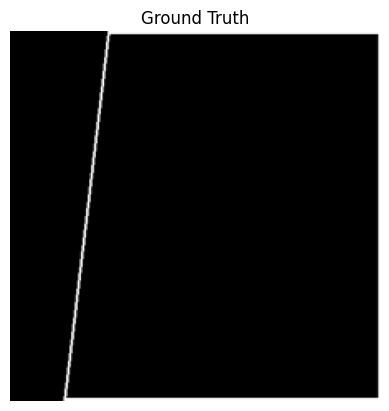

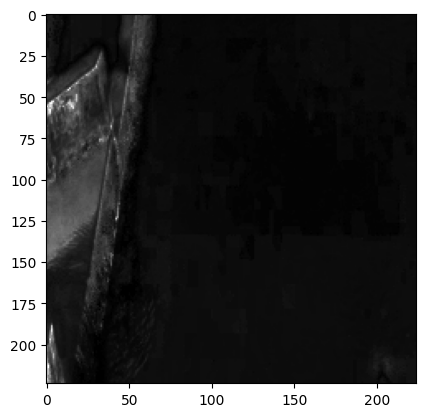

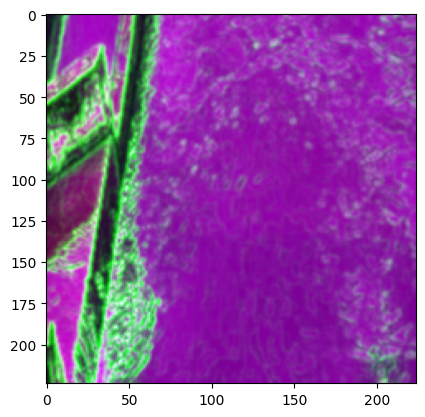

In [7]:
# 檢查 DataLoader 是否成功載入 image 和 ground truth
data_iter = iter(val_loader)
images, labels = next(data_iter)
print(images.shape, labels.shape)
image, label = images[0], labels[0]

image = image.numpy()
label = label.numpy()


image = np.transpose(image, (1, 2, 0))
label = np.transpose(label, (1, 2, 0))

plt.imshow(label[:, :, 0], cmap='gray')
plt.title('Ground Truth')
plt.axis('off')
plt.show()

plt.imshow(image[:, :, 3:4], cmap='gray')
plt.show()




A_image = image[:, :, 0:3]
if A_image.min() < 0 or A_image.max() > 1:
    A_image = (A_image - A_image.min()) / (A_image.max() - A_image.min())
    
plt.imshow(A_image)
plt.show()

## **Model**

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def normal_init(module, mean=0, std=1, bias=0):
    if hasattr(module, 'weight') and module.weight is not None:
        nn.init.normal_(module.weight, mean, std)
    if hasattr(module, 'bias') and module.bias is not None:
        nn.init.constant_(module.bias, bias)


def constant_init(module, val, bias=0):
    if hasattr(module, 'weight') and module.weight is not None:
        nn.init.constant_(module.weight, val)
    if hasattr(module, 'bias') and module.bias is not None:
        nn.init.constant_(module.bias, bias)


class DySample(nn.Module):
    def __init__(self, in_channels, scale=2, style='lp', groups=4, dyscope=False):
        super().__init__()
        self.scale = scale
        self.style = style
        self.groups = groups
        assert style in ['lp', 'pl']
        if style == 'pl':
            assert in_channels >= scale ** 2 and in_channels % scale ** 2 == 0
        assert in_channels >= groups and in_channels % groups == 0

        if style == 'pl':
            in_channels = in_channels // scale ** 2
            out_channels = 2 * groups
        else:
            out_channels = 2 * groups * scale ** 2

        self.offset = nn.Conv2d(in_channels, out_channels, 1)
        normal_init(self.offset, std=0.001)
        if dyscope:
            self.scope = nn.Conv2d(in_channels, out_channels, 1, bias=False)
            constant_init(self.scope, val=0.)

        self.register_buffer('init_pos', self._init_pos())

    def _init_pos(self):
        h = torch.arange((-self.scale + 1) / 2, (self.scale - 1) / 2 + 1) / self.scale
        return torch.stack(torch.meshgrid([h, h])).transpose(1, 2).repeat(1, self.groups, 1).reshape(1, -1, 1, 1)

    def sample(self, x, offset):
        B, _, H, W = offset.shape
        offset = offset.view(B, 2, -1, H, W)
        coords_h = torch.arange(H) + 0.5
        coords_w = torch.arange(W) + 0.5
        coords = torch.stack(torch.meshgrid([coords_w, coords_h])
                             ).transpose(1, 2).unsqueeze(1).unsqueeze(0).type(x.dtype).to(x.device)
        normalizer = torch.tensor([W, H], dtype=x.dtype, device=x.device).view(1, 2, 1, 1, 1)
        coords = 2 * (coords + offset) / normalizer - 1
        coords = F.pixel_shuffle(coords.view(B, -1, H, W), self.scale).view(
            B, 2, -1, self.scale * H, self.scale * W).permute(0, 2, 3, 4, 1).contiguous().flatten(0, 1)
        return F.grid_sample(x.reshape(B * self.groups, -1, H, W), coords, mode='bilinear',
                             align_corners=False, padding_mode="border").view(B, -1, self.scale * H, self.scale * W)

    def forward_lp(self, x):
        if hasattr(self, 'scope'):
            offset = self.offset(x) * self.scope(x).sigmoid() * 0.5 + self.init_pos
        else:
            offset = self.offset(x) * 0.25 + self.init_pos
        return self.sample(x, offset)

    def forward_pl(self, x):
        x_ = F.pixel_shuffle(x, self.scale)
        if hasattr(self, 'scope'):
            offset = F.pixel_unshuffle(self.offset(x_) * self.scope(x_).sigmoid(), self.scale) * 0.5 + self.init_pos
        else:
            offset = F.pixel_unshuffle(self.offset(x_), self.scale) * 0.25 + self.init_pos
        return self.sample(x, offset)

    def forward(self, x):
        if self.style == 'pl':
            return self.forward_pl(x)
        return self.forward_lp(x)
    


In [9]:
import torch
import torch.nn as nn
import torchvision.models as models



class DecoderBlock(nn.Module):
    def __init__(self, in_channel, mid_channel, out_channel, kernel_size, dilation, padding, upsample):
        super(DecoderBlock, self).__init__()

        modules = [
            nn.Conv2d(in_channel, mid_channel, kernel_size=kernel_size, dilation=dilation, padding=padding),
            nn.BatchNorm2d(mid_channel),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channel, mid_channel, kernel_size=kernel_size, dilation=dilation, padding=padding),
            nn.BatchNorm2d(mid_channel),
            nn.ReLU(inplace=True),
            nn.Conv2d(mid_channel, out_channel, kernel_size=kernel_size, dilation=dilation, padding=padding),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(inplace=True)
        ]
        #如果upsample=True，則會做upsmapling
        if upsample:
            modules.append(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False))
        self.block = nn.Sequential(*modules)
    def forward(self, x):
        return self.block(x)

class Squeeze_Excite_Block(nn.Module):
    def __init__(self, channel, reduction=16):
        super(Squeeze_Excite_Block, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c)
        y = self.fc(y).view(b, c, 1, 1)
        return x * y.expand_as(x)


class ASPP(nn.Module):
    def __init__(self, in_dims, out_dims, rate=[1, 6, 12]):
        super(ASPP, self).__init__()

        self.aspp_block1 = nn.Sequential(
            nn.Conv2d(
                in_dims, out_dims, 3, stride=1, padding=rate[0], dilation=rate[0]
            ),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_dims),
        )
        self.aspp_block2 = nn.Sequential(
            nn.Conv2d(
                in_dims, out_dims, 3, stride=1, padding=rate[1], dilation=rate[1]
            ),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_dims),
        )
        self.aspp_block3 = nn.Sequential(
            nn.Conv2d(
                in_dims, out_dims, 3, stride=1, padding=rate[2], dilation=rate[2]
            ),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_dims),
        )

        self.output = nn.Conv2d(len(rate) * out_dims, out_dims, 1)
        self._init_weights()

    def forward(self, x):
        x1 = self.aspp_block1(x)
        x2 = self.aspp_block2(x)
        x3 = self.aspp_block3(x)
        out = torch.cat([x1, x2, x3], dim=1)
        return self.output(out)

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight)
            elif isinstance(m, nn.BatchNorm2d):
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    
class AttentionBlock(nn.Module):
    def __init__(self, input_encoder, input_decoder, output_dim):
        super(AttentionBlock, self).__init__()

        self.conv_encoder = nn.Sequential(
            nn.BatchNorm2d(input_encoder),
            nn.ReLU(),
            nn.Conv2d(input_encoder, output_dim, 3, padding=1),
        )

        self.conv_decoder = nn.Sequential(
            nn.BatchNorm2d(input_decoder),
            nn.ReLU(),
            nn.Conv2d(input_decoder, output_dim, 3, padding=1),
        )

        self.conv_attn = nn.Sequential(
            nn.BatchNorm2d(output_dim),
            nn.ReLU(),

            nn.Conv2d(output_dim, 1, 1),
        )

    def forward(self, x1, x2):
        out = self.conv_encoder(x1) + self.conv_decoder(x2)
        out = self.conv_attn(out)
        return out * x2

class SimpleModel(nn.Module):
    def __init__(self, n_channels, n_classes):
        super(SimpleModel, self).__init__()

        # 載入resnet34作為pre-trainded model
        resnet = models.resnet34(weights='ResNet34_Weights.DEFAULT')

        ## -------------Encoder--------------
        self.inconv = nn.Conv2d(n_channels, 64, 3, padding=1)
        self.inbn = nn.BatchNorm2d(64)
        self.inrelu = nn.ReLU(inplace=True)

        self.encoder1 = resnet.layer1
        self.encoder2 = resnet.layer2

        self.upencoder2 = DecoderBlock(128, 64, 64, 3, dilation=1, padding=1, upsample=False)
        self.DySample4 = DySample(64)

        self.upencoder32 = DecoderBlock(128, 64, 64, 3, dilation=1, padding=1, upsample=False)
        self.DySample5 = DySample(64)

        self.encoder3 = resnet.layer3
        self.upencoder3 = DecoderBlock(256, 128, 128, 3, dilation=1, padding=1, upsample=False)
        self.DySample6 = DySample(128)

        self.encoder4 = resnet.layer4
        

        ## -------------Bridge--------------
        #改成ASPP
        self.bridge = ASPP(512, 512)

        ## -------------Decoder--------------
        #在UPsample的時候,先經過attention block
        self.attention4 = AttentionBlock(512, 512, 512)
        self.decoder4 = DecoderBlock(1024, 512, 256, 3, dilation=1, padding=1, upsample=False)
        self.DySample1 = DySample(256)

        self.attention3 = AttentionBlock(256, 256, 256)
        self.decoder3 = DecoderBlock(512, 256, 128, 3, dilation=1, padding=1, upsample=False)
        self.DySample2 = DySample(128)

        self.attention2 = AttentionBlock(128, 128, 128)
        self.decoder2 = DecoderBlock(256, 128, 64, 3, dilation=1, padding=1, upsample=False)
        self.DySample3 = DySample(64)

        self.attention1 = AttentionBlock(64, 64, 64)
        self.decoder1 = DecoderBlock(64*4, 64, 64, 3, dilation=1, padding=1, upsample=False)


        ## -------------Final Convolution Layer--------------
        self.final_conv = nn.Conv2d(64, n_classes, 1, padding=0)

        #self.deep_supervision0 = nn.Conv2d(512, n_classes, kernel_size=1)



    def forward(self, x):
        hx = self.inrelu(self.inbn(self.inconv(x)))

        e1 = self.encoder1(hx) #64 224 224
        e2 = self.encoder2(e1) #128 112 112
        e2_up = self.upencoder2(e2) #64 , 224 , 224
        e2_up = self.DySample4(e2_up)
    


        e3 = self.encoder3(e2) #256 56 56
        e3_up = self.upencoder3(e3) #128 ,112 , 112
        e3_up = self.DySample6(e3_up)
        e32_up = self.upencoder32(e3_up) #64 , 224 , 224
        e32_up = self.DySample5(e32_up)

        e4 = self.encoder4(e3)
        b = self.bridge(e4)


        d4 = self.decoder4(torch.cat((e4, b), dim=1))
        d4 = self.DySample1(d4)

        d3 = self.attention3(e3, d4)
        d3 = self.decoder3(torch.cat((e3, d3), dim=1))# 256,56,56
        d3 = self.DySample2(d3)

        d2 = self.attention2(e2, d3)
        d2 = self.decoder2(torch.cat((e2, d2), dim=1)) #64 112 112
        d2 = self.DySample3(d2)

        d1 = self.attention1(e1, d2)
        d1 = self.decoder1(torch.cat((e1,e32_up,e2_up, d1), dim=1)) #64 224 224


        out = self.final_conv(d1)

        return torch.sigmoid(out) 

In [10]:
import torch

torch.cuda.empty_cache()

In [11]:
model = SimpleModel(n_classes=1, n_channels=4)
device = torch.device('cuda')  # 仅指定一个GPU
model = model.to(device)
#model.load_state_dict(torch.load('/kaggle/input/ai-cup-model/single_gpu_model_RI_ALL_3.pth'))
if torch.cuda.device_count() > 1:
    print("Let's use", torch.cuda.device_count(), "GPUs!")
    # 将模型放到多个 GPU 上
    model = nn.DataParallel(model)
else:
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
#model.load_state_dict(torch.load('/kaggle/input/ai-cup-model/single_gpu_model_RI_attention.pth'))

summary(model, (4, 224, 224))

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 147MB/s]
/opt/conda/lib/python3.10/site-packages/torch/functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/TensorShape.cpp:3526.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Let's use 2 GPUs!
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           2,368
            Conv2d-2         [-1, 64, 224, 224]           2,368
       BatchNorm2d-3         [-1, 64, 224, 224]             128
       BatchNorm2d-4         [-1, 64, 224, 224]             128
              ReLU-5         [-1, 64, 224, 224]               0
              ReLU-6         [-1, 64, 224, 224]               0
            Conv2d-7         [-1, 64, 224, 224]          36,864
            Conv2d-8         [-1, 64, 224, 224]          36,864
       BatchNorm2d-9         [-1, 64, 224, 224]             128
             ReLU-10         [-1, 64, 224, 224]               0
      BatchNorm2d-11         [-1, 64, 224, 224]             128
             ReLU-12         [-1, 64, 224, 224]               0
           Conv2d-13         [-1, 64, 224, 224]          36,864
           Conv2d-14 

# **Define loss function**

In [12]:


class IOU(nn.Module):
    def __init__(self, size_average=True):
        super(IOU, self).__init__()
        self.size_average = size_average

    def forward(self, pred, target):
        b = pred.shape[0]
        IoU = 0.0
        for i in range(b):
            Iand1 = torch.sum(target[i, :, :, :] * pred[i, :, :, :])
            Ior1 = torch.sum(target[i, :, :, :]) + torch.sum(pred[i, :, :, :]) - Iand1
            IoU1 = Iand1 / Ior1
            IoU += (1 - IoU1)
        return IoU / b if self.size_average else IoU

class SSIM:
    def __init__(self, window_size=11, size_average=True):
        self.window_size = window_size
        self.size_average = size_average

    def __call__(self, img1, img2):
        (_, channel, _, _) = img1.size()
        window = self.create_window(self.window_size, channel)
        if img1.is_cuda:
            window = window.cuda(img1.get_device())
        window = window.type_as(img1)

        C1 = (0.01 ** 2)
        C2 = (0.03 ** 2)

        img1_mean = F.conv2d(img1, window, padding=self.window_size//2, groups=channel)
        img2_mean = F.conv2d(img2, window, padding=self.window_size//2, groups=channel)

        img1_var = F.conv2d(img1 ** 2, window, padding=self.window_size//2, groups=channel) - img1_mean ** 2
        img2_var = F.conv2d(img2 ** 2, window, padding=self.window_size//2, groups=channel) - img2_mean ** 2
        img12_covar = F.conv2d(img1 * img2, window, padding=self.window_size//2, groups=channel) - img1_mean * img2_mean

        numerator = (2 * img1_mean * img2_mean + C1) * (2 * img12_covar + C2)
        denominator = (img1_mean ** 2 + img2_mean ** 2 + C1) * (img1_var + img2_var + C2)

        ssim_map = numerator / denominator

        if self.size_average:
            return ssim_map.mean()
        else:
            return ssim_map.mean(1).mean(1).mean(1)

    def create_window(self, window_size, channel):
        sigma = 1.5
        grid = torch.arange(window_size).float()
        gaussian = torch.exp(-((grid - window_size//2) ** 2) / (2 * sigma ** 2))
        window1d = gaussian / gaussian.sum()
        window2d = window1d.unsqueeze(0) * window1d.unsqueeze(1)
        window = window2d.unsqueeze(0).unsqueeze(0).expand(channel, 1, window_size, window_size).contiguous()
        return window

def dice_coefficient(predicted, target, smooth=1.):
    intersection = (predicted * target).sum()
    union = predicted.sum() + target.sum()

    dice = (2. * intersection + smooth) / (union + smooth)
    return 1 - dice

def soft_dice_loss_module(prediction, target, epsilon=1e-6):
    intersection = (prediction * target).sum()
    union = prediction.sum() + target.sum()
    dice_score = 2.0 * (intersection + epsilon) / (union + epsilon)
    soft_dice_loss = 1.0 - dice_score
    return soft_dice_loss

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = torch.flatten(y_true)
    y_pred_f = torch.flatten(y_pred)
    intersection = torch.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (torch.sum(y_true_f) + torch.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)


def auto_weight_bce(y_hat_log, y):
    with torch.no_grad():
        beta = y.mean(dim=[2, 3], keepdims=True)
    logit_1 = F.logsigmoid(y_hat_log)
    logit_0 = F.logsigmoid(-y_hat_log)
    loss = -(1 - beta) * logit_1 * y - beta * logit_0 * (1 - y)
    return loss.mean()
    
def tversky_loss(y_true, y_pred, alpha=0.25, beta=0.75, smooth=1e-6):
    y_true = y_true.float()
    y_pred = y_pred.float()
    
    true_pos = torch.sum(y_true * y_pred)
    false_neg = torch.sum(y_true * (1 - y_pred))
    false_pos = torch.sum((1 - y_true) * y_pred)
    
    tversky_index = (true_pos + smooth) / (true_pos + alpha * false_pos + beta * false_neg + smooth)
    return 1 - tversky_index

def fbeta_loss(y_true, y_pred, beta=0.3, smooth=1e-6):
    y_true = y_true.float()
    y_pred = y_pred.float()
    
    true_pos = torch.sum(y_true * y_pred)
    false_neg = torch.sum(y_true * (1 - y_pred))
    false_pos = torch.sum((1 - y_true) * y_pred)
    
    precision = true_pos / (true_pos + false_pos + smooth)
    recall = true_pos / (true_pos + false_neg + smooth)
    
    f_beta = (1 + beta**2) * precision * recall / (beta**2 * precision + recall + smooth)
    return 1 - f_beta


def loss_function(predicted,target):
    #loss1 = dice_coefficient(predicted,target)
    loss2 = iou_loss_module(predicted,target)
    #loss2 = dice_loss(predicted,target)
    #loss3 = fbeta_loss(predicted,target)
    loss1 = tversky_loss(predicted,target)
    return  loss1*0.2 +loss2





iou_loss_module = IOU(size_average=True)
bce_loss_module = nn.BCEWithLogitsLoss()
ssim_loss_module = SSIM(window_size=11, size_average=True)

# **Training**

In [13]:
val_root_tset = "/kaggle/input/ai-cup/AI_CUP3zip/val/"
val_dataset_test = TestlDataset(image_root=os.path.join(val_root_tset, "TRA_RI_img"), img_size=224)
val_loader_test = DataLoader(dataset=val_dataset_test, batch_size=4, shuffle=False, pin_memory=True)
pred_root = '/kaggle/input/ai-cup/AI_CUP3zip/val/TRA_RI_label_img'

def evaluate_model(model):
    model.eval()
    FMv2 = FmeasureV2(
        metric_handlers={
            "fm": FmeasureHandler(with_dynamic=True, with_adaptive=False, beta=0.3),
        }
    )

    with torch.no_grad():
        for images, names in val_loader_test:
            images = images.cuda()
            results = model(images)
            results = F.interpolate(results, size=(240, 428), mode='bilinear', align_corners=False)
            results = results.data.cpu().numpy()


            for idx, name in enumerate(names):
                res = results[idx].squeeze()
                mask = res * 255  # 模型輸出的結果
                mask = (mask > 127).astype(np.uint8) * 255
                

                # 加載對應的 ground truth
                pred_path = os.path.join(pred_root, name)
                pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
                FMv2.step(pred=pred, gt=mask)

    fmv2 = FMv2.get_results()
    return fmv2["fm"]["dynamic"].mean()

# 評估模型
aaa = evaluate_model(model)
print(aaa)

0.1711011145264259


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 1
----------------wait-------------------
calculate FMv2 :
0.6285685140887878
----------------wait-------------------


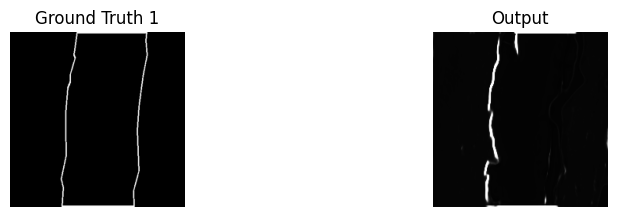

Model saved at epoch 0
Epoch [1/130], Train Loss: 1.0355, Val Loss: 0.7720
Train IOU: 0.8671, Train BCE: 0.7820
Val IOU: 0.6596


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 2
----------------wait-------------------
calculate FMv2 :
0.5801637583965461
----------------wait-------------------


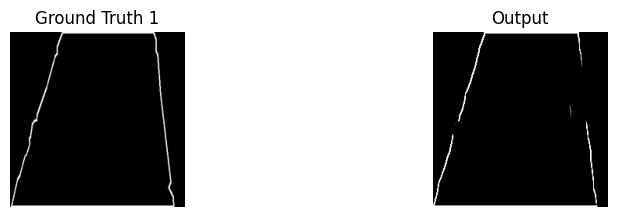

Epoch [2/130], Train Loss: 0.7556, Val Loss: 0.6277
Train IOU: 0.6516, Train BCE: 0.6972
Val IOU: 0.5570


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 3
----------------wait-------------------
calculate FMv2 :
0.584252853779684
----------------wait-------------------


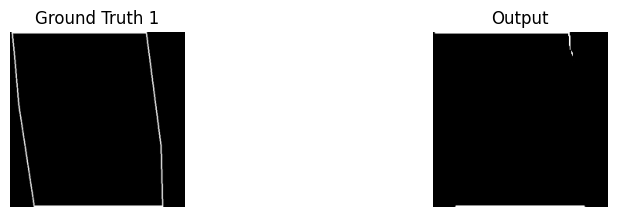

Epoch [3/130], Train Loss: 0.7077, Val Loss: 0.6169
Train IOU: 0.6164, Train BCE: 0.6947
Val IOU: 0.5466


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 4
----------------wait-------------------
calculate FMv2 :
0.6083415823180633
----------------wait-------------------


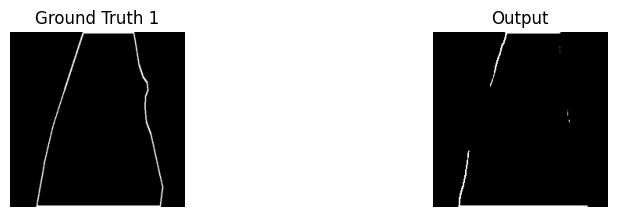

Epoch [4/130], Train Loss: 0.6934, Val Loss: 0.5932
Train IOU: 0.6050, Train BCE: 0.6944
Val IOU: 0.5279


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Epoch [5/130], Train Loss: 0.6918, Val Loss: 0.5939
Train IOU: 0.6042, Train BCE: 0.6943
Val IOU: 0.5290


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 6
----------------wait-------------------
calculate FMv2 :
0.5973186821390355
----------------wait-------------------


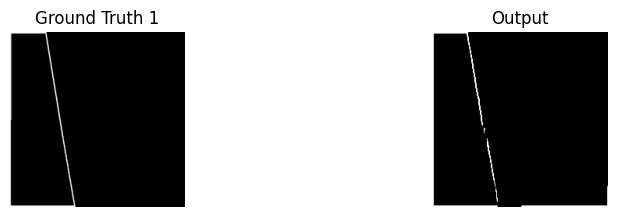

Epoch [6/130], Train Loss: 0.6843, Val Loss: 0.5917
Train IOU: 0.5977, Train BCE: 0.6942
Val IOU: 0.5288


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 7
----------------wait-------------------
calculate FMv2 :
0.6170749926911143
----------------wait-------------------


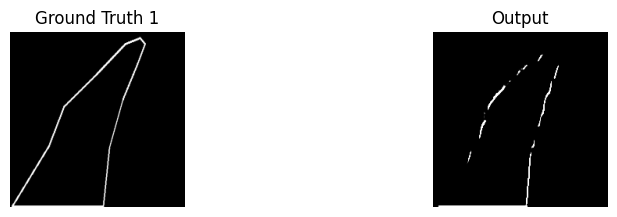

Epoch [7/130], Train Loss: 0.6714, Val Loss: 0.5771
Train IOU: 0.5869, Train BCE: 0.6941
Val IOU: 0.5151


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.67batch/s]


Epoch [8/130], Train Loss: 0.6680, Val Loss: 0.5829
Train IOU: 0.5840, Train BCE: 0.6940
Val IOU: 0.5191


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [9/130], Train Loss: 0.6738, Val Loss: 0.5802
Train IOU: 0.5887, Train BCE: 0.6941
Val IOU: 0.5162


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Epoch [10/130], Train Loss: 0.6660, Val Loss: 0.5853
Train IOU: 0.5822, Train BCE: 0.6940
Val IOU: 0.5201


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 11
----------------wait-------------------
calculate FMv2 :
0.622454362295379
----------------wait-------------------


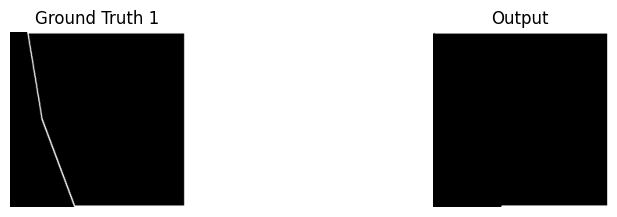

Model saved at epoch 10
Epoch [11/130], Train Loss: 0.6617, Val Loss: 0.5742
Train IOU: 0.5784, Train BCE: 0.6940
Val IOU: 0.5118


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 12
----------------wait-------------------
calculate FMv2 :
0.6224502175645955
----------------wait-------------------


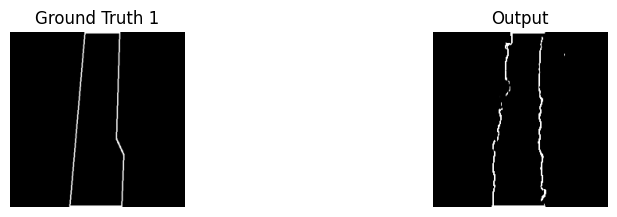

Epoch [12/130], Train Loss: 0.6584, Val Loss: 0.5713
Train IOU: 0.5755, Train BCE: 0.6940
Val IOU: 0.5099


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Epoch [13/130], Train Loss: 0.6604, Val Loss: 0.5816
Train IOU: 0.5772, Train BCE: 0.6940
Val IOU: 0.5195


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 14
----------------wait-------------------
calculate FMv2 :
0.6355727299321183
----------------wait-------------------


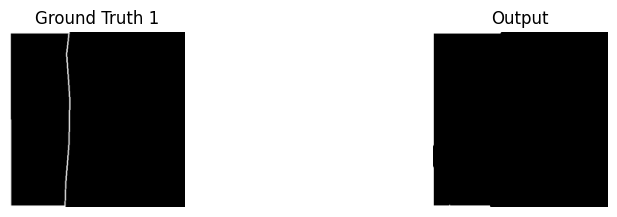

Epoch [14/130], Train Loss: 0.6544, Val Loss: 0.5704
Train IOU: 0.5721, Train BCE: 0.6939
Val IOU: 0.5062


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 15
----------------wait-------------------
calculate FMv2 :
0.6363821273033654
----------------wait-------------------


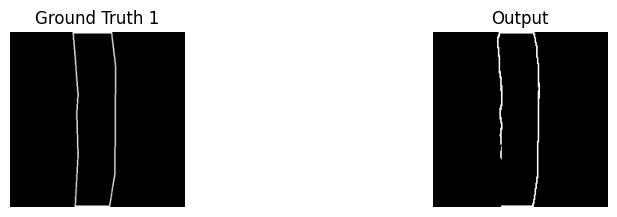

Epoch [15/130], Train Loss: 0.6496, Val Loss: 0.5646
Train IOU: 0.5683, Train BCE: 0.6938
Val IOU: 0.5024


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [16/130], Train Loss: 0.6553, Val Loss: 0.5647
Train IOU: 0.5730, Train BCE: 0.6939
Val IOU: 0.5029


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [17/130], Train Loss: 0.6500, Val Loss: 0.5681
Train IOU: 0.5683, Train BCE: 0.6939
Val IOU: 0.5076


...

Epoch [18/130], Train Loss: 0.6499, Val Loss: 0.5664
Train IOU: 0.5683, Train BCE: 0.6939
Val IOU: 0.5028


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Learning rate adjusted at epoch 19
Epoch [19/130], Train Loss: 0.6453, Val Loss: 0.5656
Train IOU: 0.5648, Train BCE: 0.6937
Val IOU: 0.5045


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 20
----------------wait-------------------
calculate FMv2 :
0.6412925813566575
----------------wait-------------------


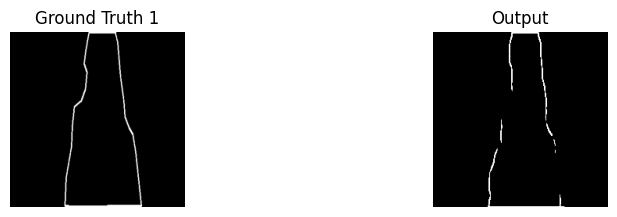

Epoch [20/130], Train Loss: 0.6302, Val Loss: 0.5527
Train IOU: 0.5528, Train BCE: 0.6933
Val IOU: 0.4930


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 21
----------------wait-------------------
calculate FMv2 :
0.6433358279785203
----------------wait-------------------


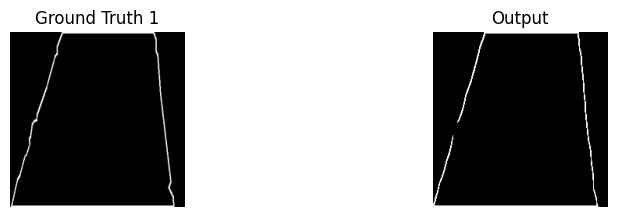

Model saved at epoch 20
Epoch [21/130], Train Loss: 0.6291, Val Loss: 0.5512
Train IOU: 0.5520, Train BCE: 0.6933
Val IOU: 0.4918


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [22/130], Train Loss: 0.6294, Val Loss: 0.5555
Train IOU: 0.5521, Train BCE: 0.6933
Val IOU: 0.4956


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [23/130], Train Loss: 0.6290, Val Loss: 0.5566
Train IOU: 0.5517, Train BCE: 0.6933
Val IOU: 0.4974


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 24
----------------wait-------------------
calculate FMv2 :
0.6435818335542007
----------------wait-------------------


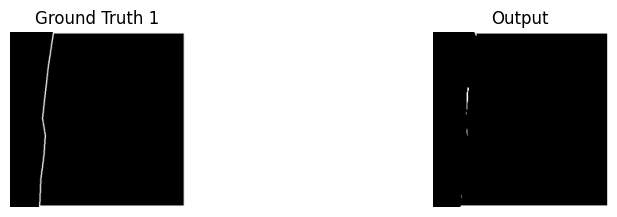

Epoch [24/130], Train Loss: 0.6240, Val Loss: 0.5476
Train IOU: 0.5477, Train BCE: 0.6932
Val IOU: 0.4895


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [25/130], Train Loss: 0.6302, Val Loss: 0.5533
Train IOU: 0.5528, Train BCE: 0.6933
Val IOU: 0.4940


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 26
----------------wait-------------------
calculate FMv2 :
0.6518769406924221
----------------wait-------------------


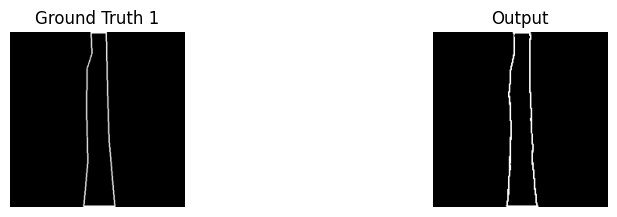

Epoch [26/130], Train Loss: 0.6136, Val Loss: 0.5415
Train IOU: 0.5387, Train BCE: 0.6931
Val IOU: 0.4835


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [27/130], Train Loss: 0.6258, Val Loss: 0.5436
Train IOU: 0.5488, Train BCE: 0.6933
Val IOU: 0.4847


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Epoch [28/130], Train Loss: 0.6063, Val Loss: 0.5442
Train IOU: 0.5331, Train BCE: 0.6928
Val IOU: 0.4850


...

Epoch [29/130], Train Loss: 0.6204, Val Loss: 0.5496
Train IOU: 0.5453, Train BCE: 0.6930
Val IOU: 0.4912


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Learning rate adjusted at epoch 30
Epoch [30/130], Train Loss: 0.6139, Val Loss: 0.5460
Train IOU: 0.5398, Train BCE: 0.6929
Val IOU: 0.4871


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 31
----------------wait-------------------
calculate FMv2 :
0.6611105007960516
----------------wait-------------------


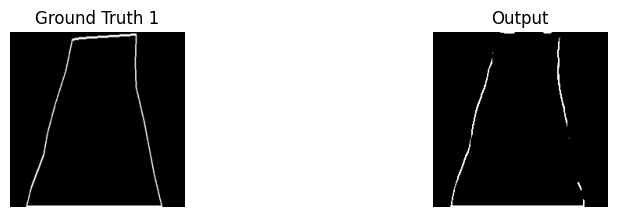

Model saved at epoch 30
Epoch [31/130], Train Loss: 0.5996, Val Loss: 0.5330
Train IOU: 0.5279, Train BCE: 0.6926
Val IOU: 0.4760


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 32
----------------wait-------------------
calculate FMv2 :
0.6614073613420006
----------------wait-------------------


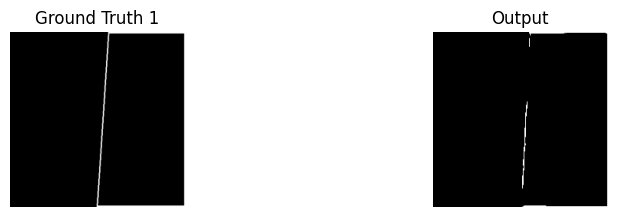

Epoch [32/130], Train Loss: 0.5944, Val Loss: 0.5329
Train IOU: 0.5236, Train BCE: 0.6925
Val IOU: 0.4757


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 33
----------------wait-------------------
calculate FMv2 :
0.6607361867597141
----------------wait-------------------


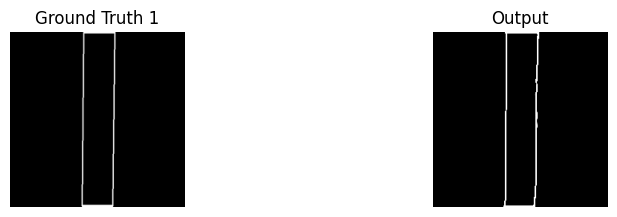

Epoch [33/130], Train Loss: 0.6004, Val Loss: 0.5325
Train IOU: 0.5286, Train BCE: 0.6926
Val IOU: 0.4755


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 34
----------------wait-------------------
calculate FMv2 :
0.6647020948511986
----------------wait-------------------


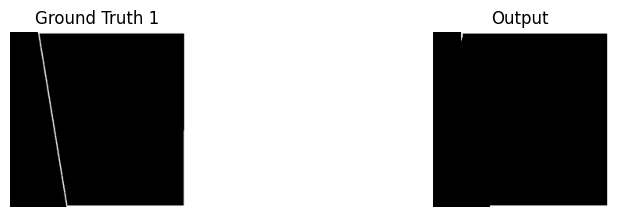

Epoch [34/130], Train Loss: 0.5916, Val Loss: 0.5277
Train IOU: 0.5213, Train BCE: 0.6925
Val IOU: 0.4715


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.73batch/s]


New best model saved at epoch 35
----------------wait-------------------
calculate FMv2 :
0.6628100910234962
----------------wait-------------------


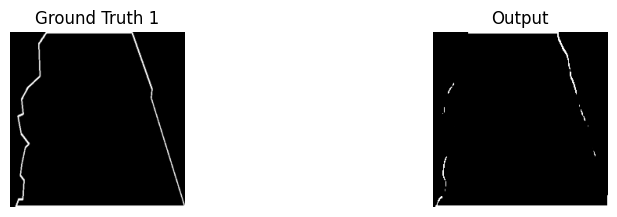

Epoch [35/130], Train Loss: 0.5902, Val Loss: 0.5262
Train IOU: 0.5201, Train BCE: 0.6925
Val IOU: 0.4707


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 36
----------------wait-------------------
calculate FMv2 :
0.6682119542173977
----------------wait-------------------


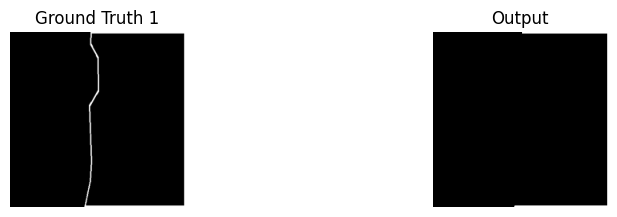

Epoch [36/130], Train Loss: 0.5988, Val Loss: 0.5228
Train IOU: 0.5273, Train BCE: 0.6926
Val IOU: 0.4676


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Epoch [37/130], Train Loss: 0.5943, Val Loss: 0.5271
Train IOU: 0.5234, Train BCE: 0.6925
Val IOU: 0.4709


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.73batch/s]


New best model saved at epoch 38
----------------wait-------------------
calculate FMv2 :
0.6636042644484383
----------------wait-------------------


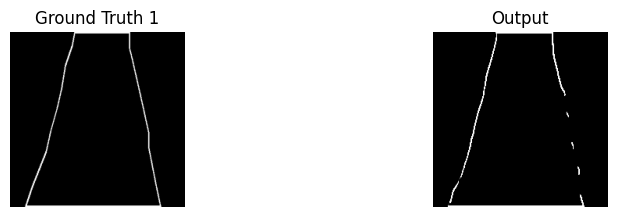

Epoch [38/130], Train Loss: 0.5863, Val Loss: 0.5224
Train IOU: 0.5168, Train BCE: 0.6924
Val IOU: 0.4683


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 39
----------------wait-------------------
calculate FMv2 :
0.6677324082209608
----------------wait-------------------


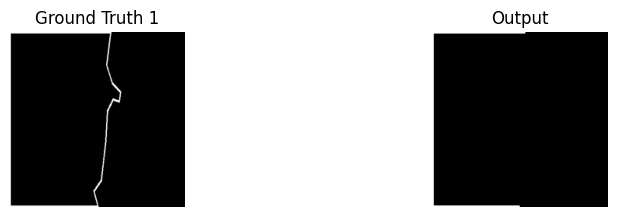

Epoch [39/130], Train Loss: 0.5769, Val Loss: 0.5196
Train IOU: 0.5089, Train BCE: 0.6923
Val IOU: 0.4653


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Epoch [40/130], Train Loss: 0.5981, Val Loss: 0.5210
Train IOU: 0.5267, Train BCE: 0.6926
Val IOU: 0.4661


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 41
----------------wait-------------------
calculate FMv2 :
0.6732063804952986
----------------wait-------------------


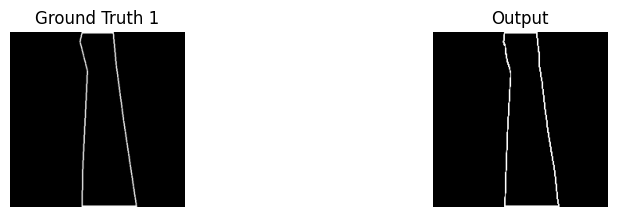

Model saved at epoch 40
Epoch [41/130], Train Loss: 0.5811, Val Loss: 0.5150
Train IOU: 0.5123, Train BCE: 0.6923
Val IOU: 0.4610


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


New best model saved at epoch 42
----------------wait-------------------
calculate FMv2 :
0.6796761950910717
----------------wait-------------------


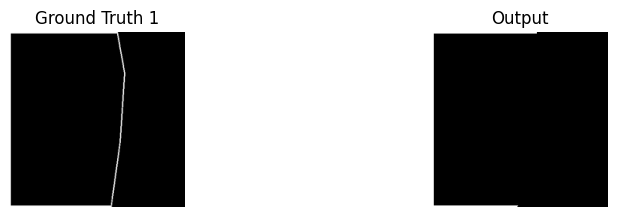

Epoch [42/130], Train Loss: 0.5806, Val Loss: 0.5110
Train IOU: 0.5121, Train BCE: 0.6923
Val IOU: 0.4573


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [43/130], Train Loss: 0.5965, Val Loss: 0.5176
Train IOU: 0.5251, Train BCE: 0.6926
Val IOU: 0.4628


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [44/130], Train Loss: 0.5929, Val Loss: 0.5172
Train IOU: 0.5221, Train BCE: 0.6926
Val IOU: 0.4626


...

Learning rate adjusted at epoch 46
Epoch [46/130], Train Loss: 0.5772, Val Loss: 0.5122
Train IOU: 0.5090, Train BCE: 0.6923
Val IOU: 0.4588


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [47/130], Train Loss: 0.5886, Val Loss: 0.5111
Train IOU: 0.5188, Train BCE: 0.6924
Val IOU: 0.4579


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 48
----------------wait-------------------
calculate FMv2 :
0.6844452472948579
----------------wait-------------------


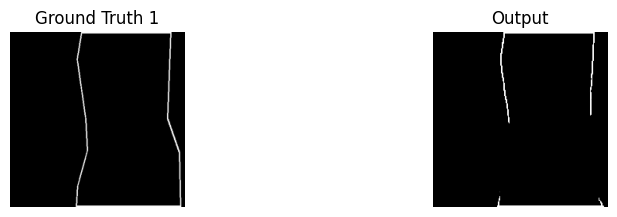

Epoch [48/130], Train Loss: 0.5703, Val Loss: 0.5033
Train IOU: 0.5033, Train BCE: 0.6922
Val IOU: 0.4509


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 49
----------------wait-------------------
calculate FMv2 :
0.6844420144090004
----------------wait-------------------


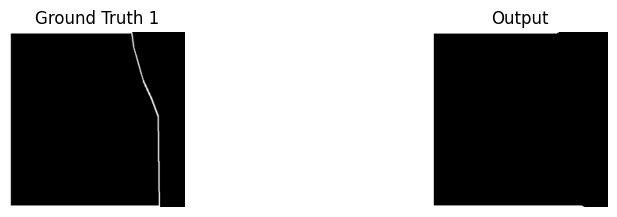

Epoch [49/130], Train Loss: 0.5696, Val Loss: 0.5026
Train IOU: 0.5028, Train BCE: 0.6921
Val IOU: 0.4502


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 50
----------------wait-------------------
calculate FMv2 :
0.6866595700733802
----------------wait-------------------


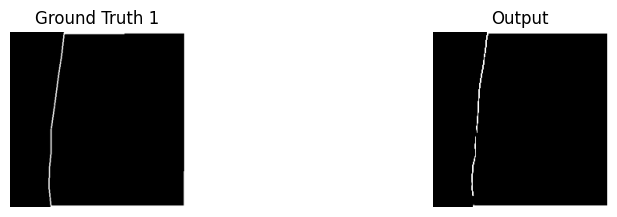

Epoch [50/130], Train Loss: 0.5686, Val Loss: 0.5013
Train IOU: 0.5019, Train BCE: 0.6921
Val IOU: 0.4490


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Model saved at epoch 50
Epoch [51/130], Train Loss: 0.5866, Val Loss: 0.5035
Train IOU: 0.5169, Train BCE: 0.6924
Val IOU: 0.4511


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.67batch/s]


Epoch [52/130], Train Loss: 0.5857, Val Loss: 0.5046
Train IOU: 0.5163, Train BCE: 0.6924
Val IOU: 0.4526


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 53
----------------wait-------------------
calculate FMv2 :
0.6899292714919002
----------------wait-------------------


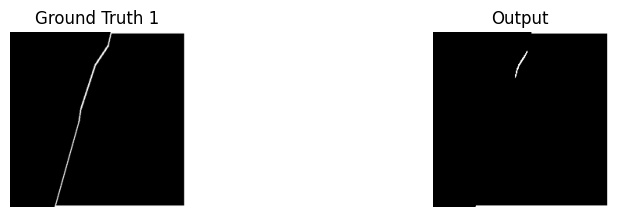

Epoch [53/130], Train Loss: 0.5588, Val Loss: 0.4975
Train IOU: 0.4936, Train BCE: 0.6920
Val IOU: 0.4458


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [54/130], Train Loss: 0.5752, Val Loss: 0.4986
Train IOU: 0.5073, Train BCE: 0.6923
Val IOU: 0.4463


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Epoch [55/130], Train Loss: 0.5797, Val Loss: 0.4994
Train IOU: 0.5111, Train BCE: 0.6923
Val IOU: 0.4476


...

Epoch [56/130], Train Loss: 0.5828, Val Loss: 0.4983
Train IOU: 0.5138, Train BCE: 0.6924
Val IOU: 0.4466


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Learning rate adjusted at epoch 57
Epoch [57/130], Train Loss: 0.5963, Val Loss: 0.5029
Train IOU: 0.5250, Train BCE: 0.6926
Val IOU: 0.4504


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.72batch/s]


New best model saved at epoch 58
----------------wait-------------------
calculate FMv2 :
0.6909904674496539
----------------wait-------------------


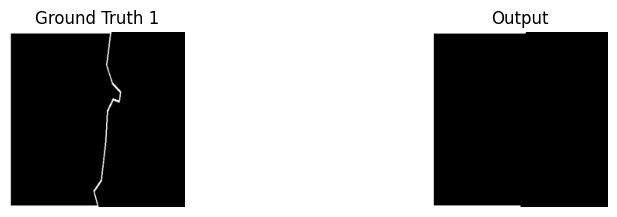

Epoch [58/130], Train Loss: 0.5642, Val Loss: 0.4969
Train IOU: 0.4979, Train BCE: 0.6921
Val IOU: 0.4451


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


New best model saved at epoch 59
----------------wait-------------------
calculate FMv2 :
0.6910513726578174
----------------wait-------------------


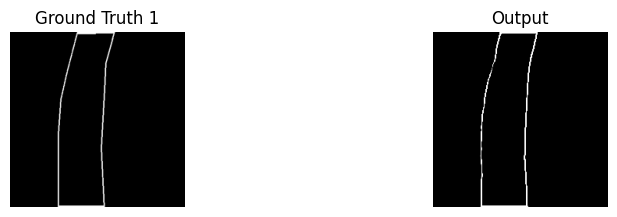

Epoch [59/130], Train Loss: 0.5629, Val Loss: 0.4958
Train IOU: 0.4969, Train BCE: 0.6921
Val IOU: 0.4444


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 60
----------------wait-------------------
calculate FMv2 :
0.6930803391755445
----------------wait-------------------


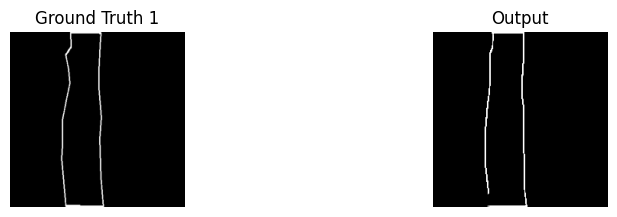

Epoch [60/130], Train Loss: 0.5715, Val Loss: 0.4949
Train IOU: 0.5044, Train BCE: 0.6922
Val IOU: 0.4434


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Model saved at epoch 60
Epoch [61/130], Train Loss: 0.5845, Val Loss: 0.4969
Train IOU: 0.5151, Train BCE: 0.6924
Val IOU: 0.4452


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [62/130], Train Loss: 0.5622, Val Loss: 0.4969
Train IOU: 0.4965, Train BCE: 0.6920
Val IOU: 0.4452


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 63
----------------wait-------------------
calculate FMv2 :
0.6954032788174911
----------------wait-------------------


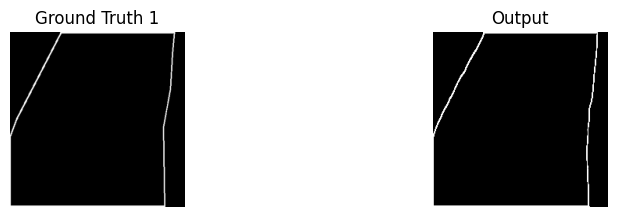

Epoch [63/130], Train Loss: 0.5520, Val Loss: 0.4929
Train IOU: 0.4878, Train BCE: 0.6919
Val IOU: 0.4415


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [64/130], Train Loss: 0.5700, Val Loss: 0.4929
Train IOU: 0.5032, Train BCE: 0.6921
Val IOU: 0.4419


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.72batch/s]


New best model saved at epoch 65
----------------wait-------------------
calculate FMv2 :
0.694248253961159
----------------wait-------------------


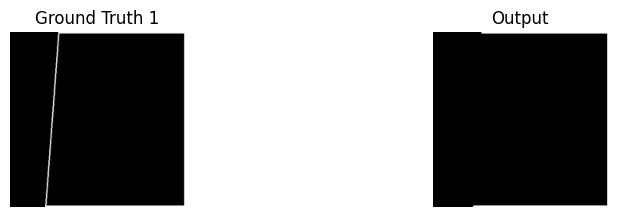

Epoch [65/130], Train Loss: 0.5697, Val Loss: 0.4919
Train IOU: 0.5029, Train BCE: 0.6921
Val IOU: 0.4411


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.73batch/s]


Epoch [66/130], Train Loss: 0.5691, Val Loss: 0.4931
Train IOU: 0.5023, Train BCE: 0.6921
Val IOU: 0.4421


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 67
----------------wait-------------------
calculate FMv2 :
0.696388816444747
----------------wait-------------------


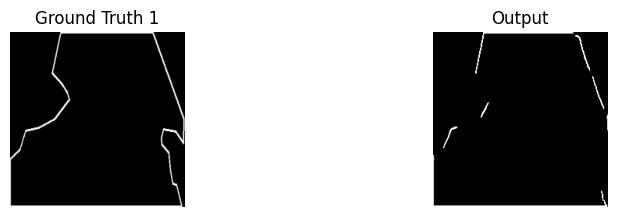

Epoch [67/130], Train Loss: 0.5597, Val Loss: 0.4909
Train IOU: 0.4944, Train BCE: 0.6920
Val IOU: 0.4399


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [68/130], Train Loss: 0.5778, Val Loss: 0.4929
Train IOU: 0.5096, Train BCE: 0.6923
Val IOU: 0.4418


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.73batch/s]


New best model saved at epoch 69
----------------wait-------------------
calculate FMv2 :
0.6952864106621824
----------------wait-------------------


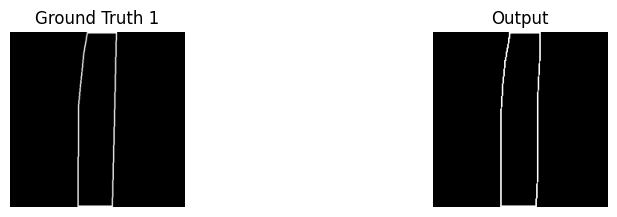

Epoch [69/130], Train Loss: 0.5687, Val Loss: 0.4908
Train IOU: 0.5020, Train BCE: 0.6921
Val IOU: 0.4401


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Epoch [70/130], Train Loss: 0.5676, Val Loss: 0.4924
Train IOU: 0.5010, Train BCE: 0.6921
Val IOU: 0.4415


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Model saved at epoch 70
Epoch [71/130], Train Loss: 0.5831, Val Loss: 0.4927
Train IOU: 0.5140, Train BCE: 0.6924
Val IOU: 0.4417


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 72
----------------wait-------------------
calculate FMv2 :
0.695581383740684
----------------wait-------------------


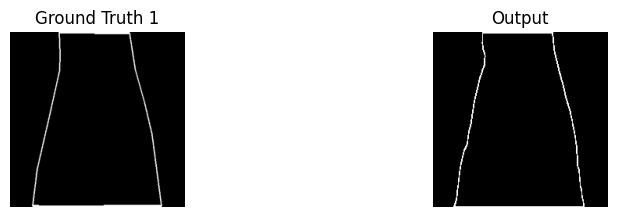

Epoch [72/130], Train Loss: 0.5672, Val Loss: 0.4903
Train IOU: 0.5006, Train BCE: 0.6921
Val IOU: 0.4397


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 73
----------------wait-------------------
calculate FMv2 :
0.6969260854879451
----------------wait-------------------


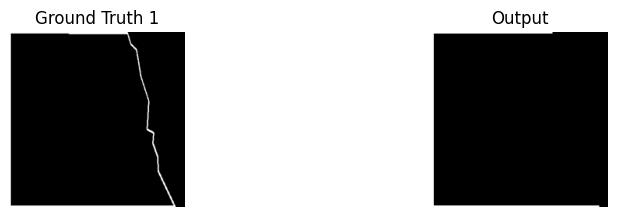

Epoch [73/130], Train Loss: 0.5578, Val Loss: 0.4901
Train IOU: 0.4928, Train BCE: 0.6920
Val IOU: 0.4393


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 74
----------------wait-------------------
calculate FMv2 :
0.69615858825157
----------------wait-------------------


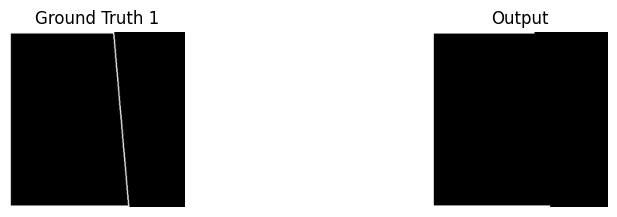

Epoch [74/130], Train Loss: 0.5636, Val Loss: 0.4891
Train IOU: 0.4976, Train BCE: 0.6921
Val IOU: 0.4388


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 75
----------------wait-------------------
calculate FMv2 :
0.6965157934037223
----------------wait-------------------


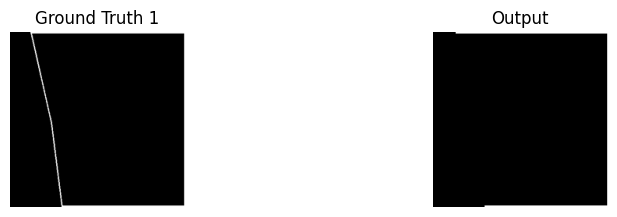

Epoch [75/130], Train Loss: 0.5572, Val Loss: 0.4879
Train IOU: 0.4923, Train BCE: 0.6920
Val IOU: 0.4380


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [76/130], Train Loss: 0.5666, Val Loss: 0.4879
Train IOU: 0.5001, Train BCE: 0.6921
Val IOU: 0.4377


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [77/130], Train Loss: 0.5755, Val Loss: 0.4886
Train IOU: 0.5077, Train BCE: 0.6922
Val IOU: 0.4378


...

Epoch [78/130], Train Loss: 0.5911, Val Loss: 0.4948
Train IOU: 0.5208, Train BCE: 0.6925
Val IOU: 0.4438


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Learning rate adjusted at epoch 79
Epoch [79/130], Train Loss: 0.5661, Val Loss: 0.4882
Train IOU: 0.4997, Train BCE: 0.6921
Val IOU: 0.4375


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 80
----------------wait-------------------
calculate FMv2 :
0.6981065575240317
----------------wait-------------------


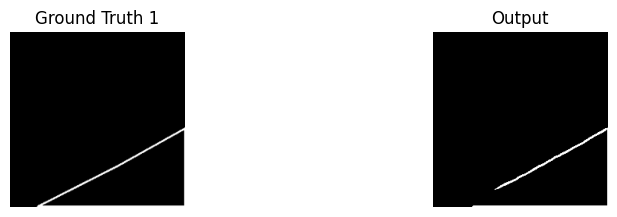

Epoch [80/130], Train Loss: 0.5563, Val Loss: 0.4876
Train IOU: 0.4914, Train BCE: 0.6920
Val IOU: 0.4375


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Model saved at epoch 80
Epoch [81/130], Train Loss: 0.5706, Val Loss: 0.4876
Train IOU: 0.5035, Train BCE: 0.6922
Val IOU: 0.4371


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [82/130], Train Loss: 0.5708, Val Loss: 0.4886
Train IOU: 0.5038, Train BCE: 0.6922
Val IOU: 0.4382


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [83/130], Train Loss: 0.5838, Val Loss: 0.4880
Train IOU: 0.5147, Train BCE: 0.6923
Val IOU: 0.4376


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 84
----------------wait-------------------
calculate FMv2 :
0.6987005928662517
----------------wait-------------------


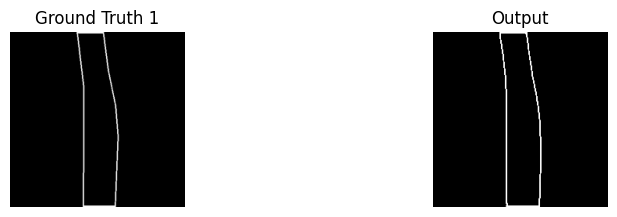

Epoch [84/130], Train Loss: 0.5702, Val Loss: 0.4870
Train IOU: 0.5031, Train BCE: 0.6922
Val IOU: 0.4368


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 85
----------------wait-------------------
calculate FMv2 :
0.6995910263298701
----------------wait-------------------


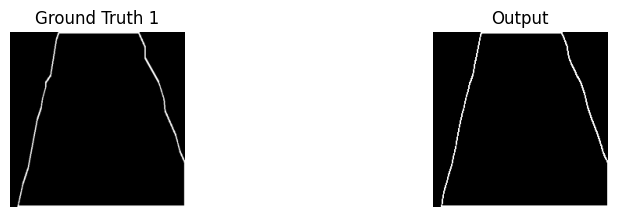

Epoch [85/130], Train Loss: 0.5452, Val Loss: 0.4860
Train IOU: 0.4820, Train BCE: 0.6918
Val IOU: 0.4360


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.76batch/s]


Epoch [86/130], Train Loss: 0.5642, Val Loss: 0.4863
Train IOU: 0.4982, Train BCE: 0.6921
Val IOU: 0.4361


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [87/130], Train Loss: 0.5701, Val Loss: 0.4874
Train IOU: 0.5032, Train BCE: 0.6921
Val IOU: 0.4371


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 88
----------------wait-------------------
calculate FMv2 :
0.7006373309738763
----------------wait-------------------


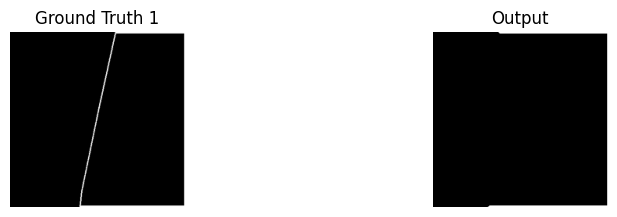

Epoch [88/130], Train Loss: 0.5637, Val Loss: 0.4855
Train IOU: 0.4977, Train BCE: 0.6921
Val IOU: 0.4354


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 89
----------------wait-------------------
calculate FMv2 :
0.7017795666241258
----------------wait-------------------


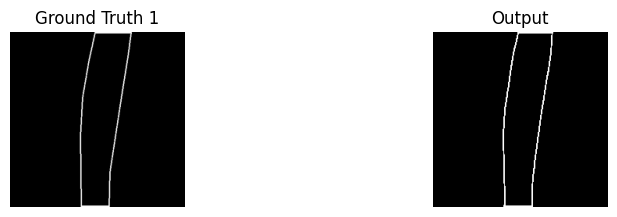

Epoch [89/130], Train Loss: 0.5634, Val Loss: 0.4847
Train IOU: 0.4974, Train BCE: 0.6921
Val IOU: 0.4346


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [90/130], Train Loss: 0.5739, Val Loss: 0.4876
Train IOU: 0.5063, Train BCE: 0.6922
Val IOU: 0.4371


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Model saved at epoch 90
Epoch [91/130], Train Loss: 0.5542, Val Loss: 0.4853
Train IOU: 0.4896, Train BCE: 0.6919
Val IOU: 0.4355


...

Epoch [92/130], Train Loss: 0.5824, Val Loss: 0.4874
Train IOU: 0.5134, Train BCE: 0.6924
Val IOU: 0.4366


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Learning rate adjusted at epoch 93
Epoch [93/130], Train Loss: 0.5536, Val Loss: 0.4849
Train IOU: 0.4891, Train BCE: 0.6919
Val IOU: 0.4350


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


New best model saved at epoch 94
----------------wait-------------------
calculate FMv2 :
0.7023299333742299
----------------wait-------------------


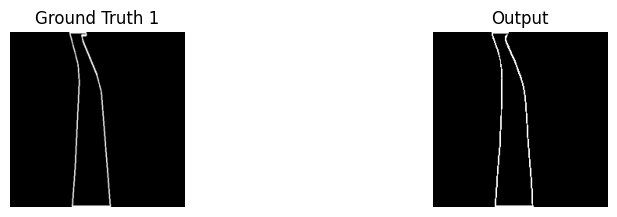

Epoch [94/130], Train Loss: 0.5537, Val Loss: 0.4845
Train IOU: 0.4893, Train BCE: 0.6919
Val IOU: 0.4343


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Epoch [95/130], Train Loss: 0.5638, Val Loss: 0.4851
Train IOU: 0.4977, Train BCE: 0.6921
Val IOU: 0.4351


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [96/130], Train Loss: 0.5731, Val Loss: 0.4847
Train IOU: 0.5055, Train BCE: 0.6922
Val IOU: 0.4347


...

Epoch [97/130], Train Loss: 0.5631, Val Loss: 0.4846
Train IOU: 0.4972, Train BCE: 0.6921
Val IOU: 0.4348


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Learning rate adjusted at epoch 98
Epoch [98/130], Train Loss: 0.5437, Val Loss: 0.4847
Train IOU: 0.4808, Train BCE: 0.6918
Val IOU: 0.4349


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 99
----------------wait-------------------
calculate FMv2 :
0.7009774256713437
----------------wait-------------------


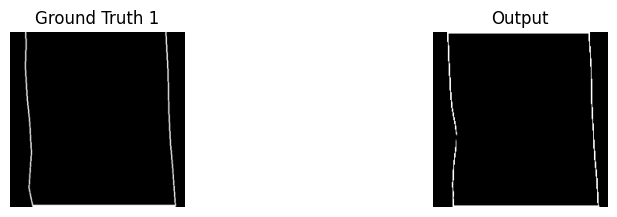

Epoch [99/130], Train Loss: 0.5785, Val Loss: 0.4840
Train IOU: 0.5103, Train BCE: 0.6923
Val IOU: 0.4343


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 100
----------------wait-------------------
calculate FMv2 :
0.701079462429798
----------------wait-------------------


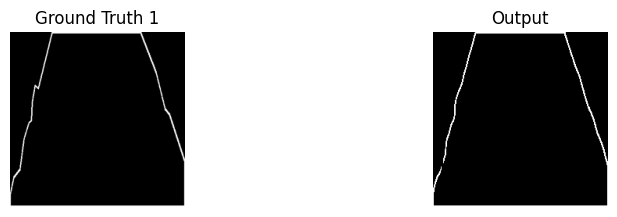

Epoch [100/130], Train Loss: 0.5439, Val Loss: 0.4840
Train IOU: 0.4809, Train BCE: 0.6918
Val IOU: 0.4342


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Model saved at epoch 100
Epoch [101/130], Train Loss: 0.5631, Val Loss: 0.4851
Train IOU: 0.4972, Train BCE: 0.6920
Val IOU: 0.4351


Validation: 100%|██████████| 12/12 [00:07<00:00,  1.66batch/s]


Epoch [102/130], Train Loss: 0.5619, Val Loss: 0.4840
Train IOU: 0.4962, Train BCE: 0.6920
Val IOU: 0.4345


...

Learning rate adjusted at epoch 104
Epoch [104/130], Train Loss: 0.5622, Val Loss: 0.4842
Train IOU: 0.4965, Train BCE: 0.6920
Val IOU: 0.4345


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [105/130], Train Loss: 0.5630, Val Loss: 0.4845
Train IOU: 0.4972, Train BCE: 0.6920
Val IOU: 0.4345


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


New best model saved at epoch 106
----------------wait-------------------
calculate FMv2 :
0.7011569118356453
----------------wait-------------------


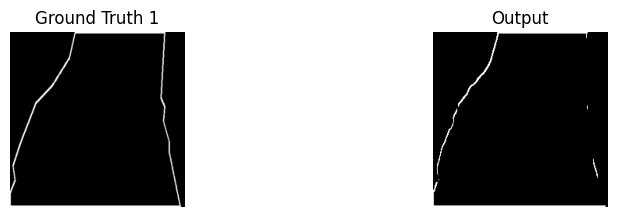

Epoch [106/130], Train Loss: 0.5622, Val Loss: 0.4833
Train IOU: 0.4965, Train BCE: 0.6920
Val IOU: 0.4338


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.74batch/s]


Epoch [107/130], Train Loss: 0.5697, Val Loss: 0.4843
Train IOU: 0.5029, Train BCE: 0.6921
Val IOU: 0.4346


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [108/130], Train Loss: 0.5715, Val Loss: 0.4842
Train IOU: 0.5043, Train BCE: 0.6922
Val IOU: 0.4343


...

Epoch [128/130], Train Loss: 0.5693, Val Loss: 0.4846
Train IOU: 0.5024, Train BCE: 0.6921
Val IOU: 0.4347


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]


Epoch [129/130], Train Loss: 0.5628, Val Loss: 0.4840
Train IOU: 0.4970, Train BCE: 0.6920
Val IOU: 0.4343


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.75batch/s]

Learning rate adjusted at epoch 130
Epoch [130/130], Train Loss: 0.5698, Val Loss: 0.4841
Train IOU: 0.5028, Train BCE: 0.6921
Val IOU: 0.4343
Training complete. Best model saved to models/best_model.pth


In [14]:
import os
import torch
import torch.optim as optim
from tqdm import tqdm
from torch.optim import Adam
from torch.optim.lr_scheduler import CyclicLR


# 設定權重儲存的路徑
save_path = 'models'
os.makedirs(save_path, exist_ok=True)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model.to(device)

initial_lr  = 0.01
epoch_num = 130
# optimizer = optim.Adam(model.parameters(), lr=initial_lr)
# scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=0)
optimizer = optim.AdamW(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.4)
best_val_loss = float('inf')
patience = 90  # 設定早停的耐心度
counter = 0  # 計數器，用於計算已經持續幾個 epoch 驗證集的損失沒有改善

# 新增一個字典來保存歷史紀錄
history = {'train_loss': [], 'val_loss': []}
accumulation_steps = 2  # 累積梯度的步數

for epoch in range(epoch_num):
    ## -------------Training stage--------------
    model.train()
    epoch_step = 0
    loss_all = 0
    iou_total = 0
    bce_total = 0
    train_loss_total = 0
    for batch_idx, (images, gts) in enumerate(tqdm(tr_loader, desc=f'Epoch {epoch+1}/{epoch_num}', unit='batch')):
        images = images.to(device)
        gts = gts.to(device)
        #outputs, deep_supervision1, deep_supervision2, deep_supervision3 = model(images)
        outputs = model(images)
        # deep1_gt = gt_downsample(gts, 4)
        # deep2_gt = gt_downsample(gts, 2)
        # deep3_gt = gt_downsample(gts, 1)
        # deep1_loss = loss_function(deep_supervision1, deep1_gt)
        # deep2_loss = loss_function(deep_supervision2, deep2_gt)
        # deep3_loss = loss_function(deep_supervision3, deep3_gt)
        #with autocast():
        loss_iou = iou_loss_module(outputs, gts)
        train_loss = loss_function(outputs, gts)
        bce_loss = bce_loss_module(outputs, gts)

        loss = train_loss #+ deep1_loss * 0.33 + deep2_loss * 0.33 + deep3_loss * 0.33

        iou_total += loss_iou.item()
        bce_total += bce_loss.item()
        #scaler.scale(loss).backward()
        loss_all += loss.item()

        loss = loss / accumulation_steps
        loss.backward()
        
        if (batch_idx + 1) % accumulation_steps == 0:
            optimizer.step()
            optimizer.zero_grad()

        epoch_step += 1

    avg_train_loss = loss_all / epoch_step
    avg_iou_loss = iou_total / epoch_step
    avg_bce_loss = bce_total / epoch_step

    history['train_loss'].append(avg_iou_loss)
    ## -------------Validation stage--------------
    model.eval()
    with torch.no_grad():
        val_loss_all = 0
        val_step = 0
        val_iou_total = 0
        new_check = 0
        for images, gts in tqdm(val_loader, desc='Validation', unit='batch'):
            images = images.to(device)
            gts = gts.to(device)
            #outputs, deep_supervision1, deep_supervision2, deep_supervision3 = model(images)
            outputs = model(images)

            loss_iou = iou_loss_module(outputs, gts)
            bce_loss = bce_loss_module(outputs, gts)
            val_loss = loss_function(outputs, gts)
            val_iou_total += loss_iou.item()
            val_loss_all += val_loss.item()
            val_step += 1

        avg_val_loss = val_loss_all / val_step
        avg_val_iou = val_iou_total / val_step


    history['val_loss'].append(avg_val_iou)
    # 儲存最好的權重
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_path = os.path.join(save_path, 'best_model.pth')
        torch.save(model.state_dict(), best_model_path)
        print('New best model saved at epoch', epoch + 1)
        counter = 0  # 重置計數器，因為有改善

        
        print("----------------wait-------------------")
        print("calculate FMv2 :")
        new_check = evaluate_model(model)
        print(new_check)
        print("----------------wait-------------------")
        plt.figure(figsize=(10, 5))
        plt.subplot(2, 2, 1)
        plt.imshow(gts[0][0].cpu().detach().numpy(), cmap='gray')
        plt.title('Ground Truth 1')
        plt.axis('off')
        
        # plt.subplot(2, 2, 2)
        # plt.imshow(deep_supervision1[0][0].cpu().detach().numpy(), cmap='gray')
        # plt.title('Deep Supervision 1')
        # plt.axis('off')
        # plt.subplot(2, 2, 3)
        # plt.imshow(deep_supervision2[0][0].cpu().detach().numpy(), cmap='gray')
        # plt.title('Deep Supervision 2')
        # plt.axis('off')
        # plt.subplot(2, 2, 4)
        # plt.imshow(deep_supervision2[0][0].cpu().detach().numpy(), cmap='gray')
        # plt.title('Deep Supervision 3')
        # plt.axis('off')
        # plt.show() 
        plt.subplot(2, 2, 2)
        plt.imshow(outputs[0][0].cpu().detach().numpy(), cmap='gray')
        plt.title('Output')
        plt.axis('off')
        plt.show()

    else:
        counter += 1  # 沒有改善，計數器加一
        if counter % 4 == 0:
            scheduler.step()
            print(f"Learning rate adjusted at epoch {epoch+1}")
    # 如果計數器達到耐心度，則停止訓練
    if counter >= patience:
        print(f'Validation loss did not improve for {patience} epochs. Early stopping...')
        break

    # 每 10 個 epoch 儲存一次權重
    if epoch % 10 == 0:
        model_save_path = os.path.join(save_path, f'Net_epoch_{epoch}.pth')
        torch.save(model.state_dict(), model_save_path)
        print(f'Model saved at epoch {epoch}')


    print(f"Epoch [{epoch + 1}/{epoch_num}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")
    print(f"Train IOU: {avg_iou_loss:.4f}, Train BCE: {avg_bce_loss:.4f}")
    print(f"Val IOU: {avg_val_iou:.4f}")
print(f"Training complete. Best model saved to {best_model_path}")


# **Testing**

In [15]:
import os
import torch
from tqdm import tqdm

model.load_state_dict(torch.load('/kaggle/working/models/best_model.pth'))
# -------------Validation stage--------------
model.eval()

with torch.no_grad():
    val_loss_all = 0
    val_step = 0

    for images, gts in tqdm(val_loader, desc='Validation', unit='batch'):
        images = images.to(device)
        gts = gts.to(device)
        #outputs, deep_sup1, deep_sup2, deep_sup3 = model(images)
        outputs = model(images)
        loss_iou = iou_loss_module(outputs, gts)
        loss_bce = bce_loss_module(outputs, gts)
        val_loss = loss_iou 
        val_loss_all += val_loss.item()
        val_step += 1

    avg_val_loss = val_loss_all / val_step

print(f"Avg Validation Loss: {avg_val_loss:.4f}")


Validation: 100%|██████████| 12/12 [00:06<00:00,  1.80batch/s]

Avg Validation Loss: 0.4338


In [16]:
val_root = "/kaggle/input/ai-cup/AI_CUP3zip/val/"
val_dataset = TestlDataset(image_root=os.path.join(val_root, "TRA_RI_img"), img_size=224)
val_loader = DataLoader(dataset=val_dataset, batch_size=4, shuffle=False, pin_memory=True)
#model.load_state_dict(torch.load('/kaggle/working/models/best_model.pth'))
model.eval()
# ts_root/label_img = save_path
save_path = 'val_result1'

os.makedirs(save_path, exist_ok=True)

with torch.no_grad():
    for images, names in val_loader:
      images = images.cuda()
      results = model(images)
      results = F.interpolate(results, size=(240, 428), mode='bilinear', align_corners=False)
      results = results.data.cpu().numpy()
      for idx, name in enumerate(names):
          res = results[idx].squeeze()
          success = cv2.imwrite(os.path.join(save_path, name), res * 255)
          if success:
              print(f"File saved successfully: {name}")
          else:
              print(f"Failed to save file: {name}")

File saved successfully: TRA_RI_2000003.png
File saved successfully: TRA_RI_2000005.png
File saved successfully: TRA_RI_2000007.png
File saved successfully: TRA_RI_2000021.png
File saved successfully: TRA_RI_2000031.png
File saved successfully: TRA_RI_2000034.png
File saved successfully: TRA_RI_2000039.png
File saved successfully: TRA_RI_2000045.png
File saved successfully: TRA_RI_2000049.png
File saved successfully: TRA_RI_2000072.png
File saved successfully: TRA_RI_2000074.png
File saved successfully: TRA_RI_2000102.png
File saved successfully: TRA_RI_2000109.png
File saved successfully: TRA_RI_2000127.png
File saved successfully: TRA_RI_2000135.png
File saved successfully: TRA_RI_2000141.png
File saved successfully: TRA_RI_2000144.png
File saved successfully: TRA_RI_2000154.png
File saved successfully: TRA_RI_2000159.png
File saved successfully: TRA_RI_2000177.png
File saved successfully: TRA_RI_2000195.png
File saved successfully: TRA_RI_2000213.png
File saved successfully: TRA_RI_

# **Evalution**

In [17]:
#設定模型預測結果的路徑
mask_root = '/kaggle/working/val_result1'
#設定 ground truth 路徑
pred_root = '/kaggle/input/ai-cup/AI_CUP3zip/val/TRA_RI_label_img'


# 計算 Mean F-measure
mask_name_list = sorted(os.listdir(mask_root))
FMv2 = FmeasureV2(
    metric_handlers={
        "fm": FmeasureHandler(with_dynamic=True, with_adaptive=False, beta=0.3),
    }
)
for i, mask_name in enumerate(mask_name_list):
    #print(f"[{i}] Processing {mask_name}...")
    mask_path = os.path.join(mask_root, mask_name)
    pred_path = os.path.join(pred_root, mask_name)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    pred = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    FMv2.step(pred=pred, gt=mask)

fmv2 = FMv2.get_results()

results = {
    "meanfm": fmv2["fm"]["dynamic"].mean()
}

print(results)
print("Eval finished!")

{'meanfm': 0.700231523473887}
Eval finished!


In [18]:
ts_root = '/kaggle/input/air-photo/35_Competition 2_public testing dataset'
ts_dataset = TestlDataset(image_root=os.path.join(ts_root, "img"), img_size=224)
ts_loader = DataLoader(dataset=ts_dataset, batch_size=16, shuffle=False, pin_memory=True)
#model.load_state_dict(torch.load('/kaggle/working/models/best_model.pth'))
model.eval()
# ts_root/label_img = save_path
save_path = 'label_img'

os.makedirs(save_path, exist_ok=True)

with torch.no_grad():
    for images, names in ts_loader:
      images = images.cuda()
      results = model(images)
      results = F.interpolate(results, size=(240, 428), mode='bilinear', align_corners=False)
      results = results.data.cpu().numpy()
      for idx, name in enumerate(names):
          res = results[idx].squeeze()
          success = cv2.imwrite(os.path.join(save_path, name), res * 255)
          if success:
              print(f"File saved successfully: {name}")
          else:
              print(f"Failed to save file: {name}")
ts_root = '/kaggle/input/ai-cup/35_Competition 2_Private Test Dataset/35_Competition 2_Private Test Dataset/'
ts_dataset = TestlDataset(image_root=os.path.join(ts_root, "img"), img_size=224)
ts_loader = DataLoader(dataset=ts_dataset, batch_size=16, shuffle=False, pin_memory=True)
#model.load_state_dict(torch.load('/kaggle/working/models/best_model.pth'))
model.eval()
# ts_root/label_img = save_path
save_path = 'label_img1'

os.makedirs(save_path, exist_ok=True)

with torch.no_grad():
    for images, names in ts_loader:
      images = images.cuda()
      results = model(images)
      results = F.interpolate(results, size=(240, 428), mode='bilinear', align_corners=False)
      results = results.data.cpu().numpy()
      for idx, name in enumerate(names):
          res = results[idx].squeeze()
          success = cv2.imwrite(os.path.join(save_path, name), res * 255)
          if success:
              print(f"File saved successfully: {name}")
          else:
              print(f"Failed to save file: {name}")
#壓縮檔案成zip檔
directory_to_compress = '/kaggle/working/label_img1'
shutil.make_archive('Private_RO', 'zip', directory_to_compress)
#壓縮檔案成zip檔
directory_to_compress = '/kaggle/working/label_img'
shutil.make_archive('PUB_RO', 'zip', directory_to_compress)

File saved successfully: PUB_RI_2000000.png
File saved successfully: PUB_RI_2000001.png
File saved successfully: PUB_RI_2000002.png
File saved successfully: PUB_RI_2000003.png
File saved successfully: PUB_RI_2000004.png
File saved successfully: PUB_RI_2000005.png
File saved successfully: PUB_RI_2000006.png
File saved successfully: PUB_RI_2000007.png
File saved successfully: PUB_RI_2000008.png
File saved successfully: PUB_RI_2000009.png
File saved successfully: PUB_RI_2000010.png
File saved successfully: PUB_RI_2000011.png
File saved successfully: PUB_RI_2000012.png
File saved successfully: PUB_RI_2000013.png
File saved successfully: PUB_RI_2000014.png
File saved successfully: PUB_RI_2000015.png
File saved successfully: PUB_RI_2000016.png
File saved successfully: PUB_RI_2000017.png
File saved successfully: PUB_RI_2000018.png
File saved successfully: PUB_RI_2000019.png
File saved successfully: PUB_RI_2000020.png
File saved successfully: PUB_RI_2000021.png
File saved successfully: PUB_RI_

'/kaggle/working/PUB_RO.zip'

# **Submission**

In [19]:
if isinstance(model, nn.DataParallel):
    model = model.module

# 保存单GPU模型
torch.save(model.state_dict(), "single_gpu_model_RO.pth")